In [1]:
import anndata as ad
import scanpy as sc

## Load data

In [2]:
# load raw data
adata = ad.read_csv("../Day-Investigation/Data/GSE151334_counts.mouse.tsv", delimiter="\t")

# transpose from R convention (cells as columns) to Python convention (cells as rows)
adata = adata.transpose()
adata

c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)


AnnData object with n_obs × n_vars = 2183 × 55293

## QC

In [3]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("Mt")

In [4]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True, log1p=True)

c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\scanpy\preprocessing\_qc.py:428: RuntimeWarning: invalid value encountered in divide
  return values / sums[:, None]


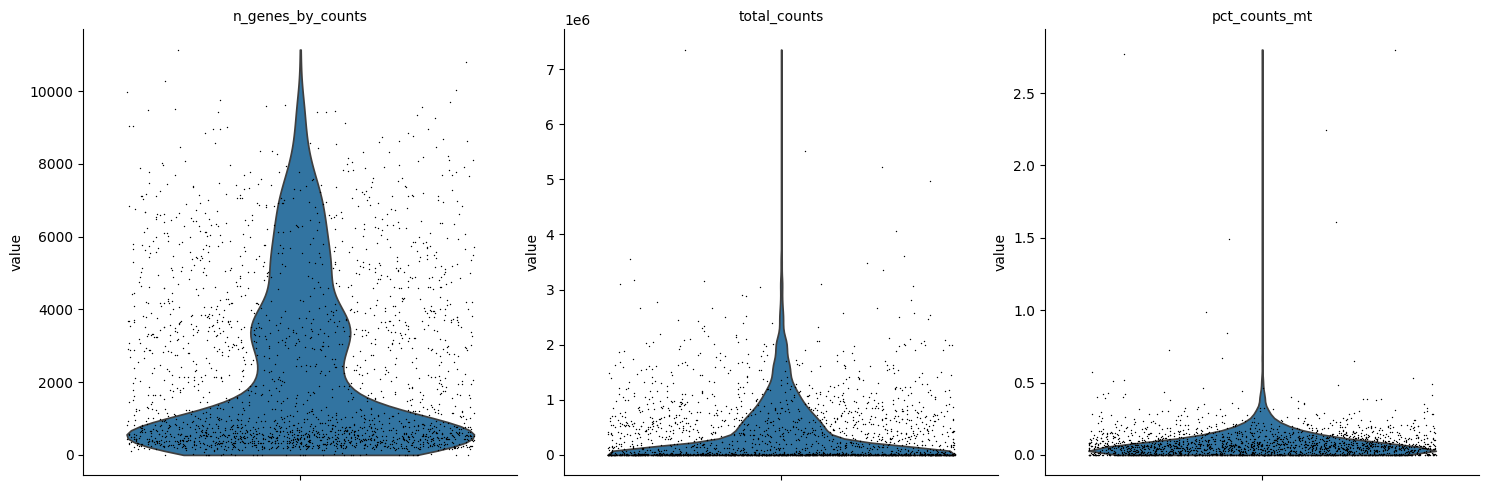

In [5]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

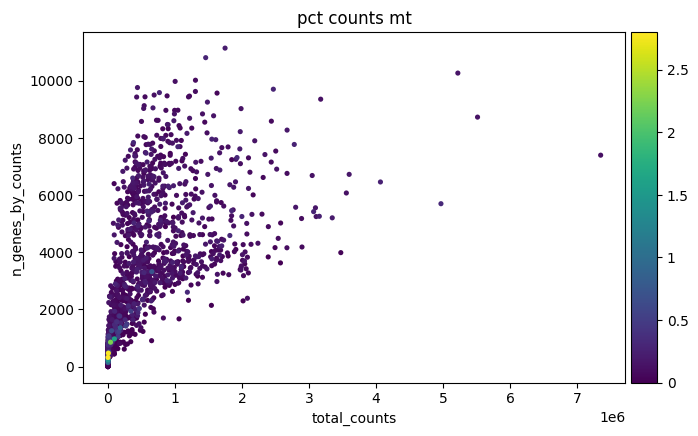

In [6]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

## Filtering & Normalization

In [7]:
# perform basic filtering for now
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [8]:
# Saving count data
adata.layers["counts"] = adata.X.copy()

In [9]:
# Normalizing to median total counts
sc.pp.normalize_total(adata)

# Logarithmize the data
sc.pp.log1p(adata)

In [10]:
adata

AnnData object with n_obs × n_vars = 2149 × 37130
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'
    uns: 'log1p'
    layers: 'counts'

In [11]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000)

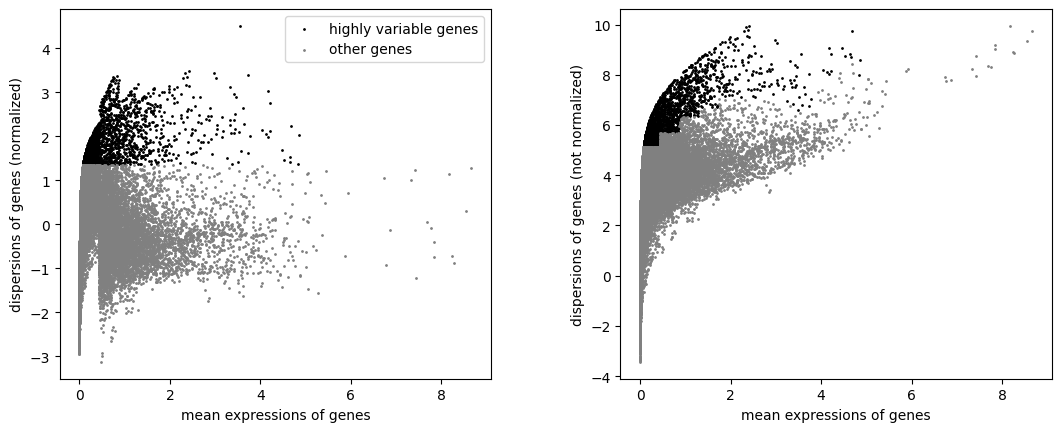

In [12]:
sc.pl.highly_variable_genes(adata)

## Dimensionality Reduction: PCA

In [13]:
sc.tl.pca(adata)

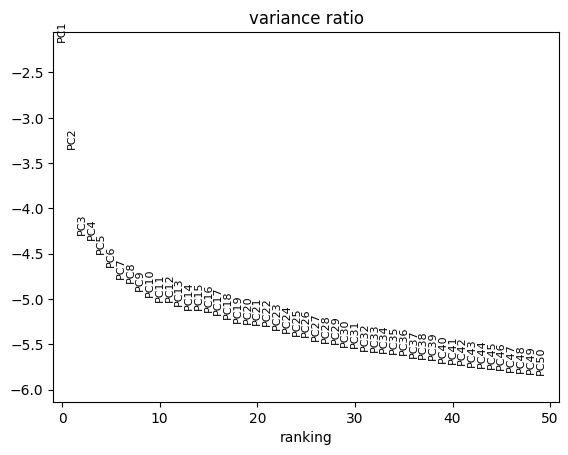

In [14]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

## Nearest Neighbour graph and UMAP on PCA space

In [15]:
sc.pp.neighbors(adata, n_pcs=15)

c:\Users\willi\Documents\ProjectPaper\M5R_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
sc.tl.umap(adata, n_components=15)

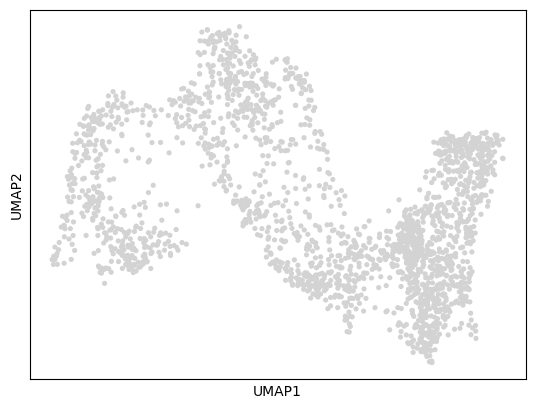

In [17]:
sc.pl.umap(adata)

In [18]:
sc.tl.draw_graph(adata)

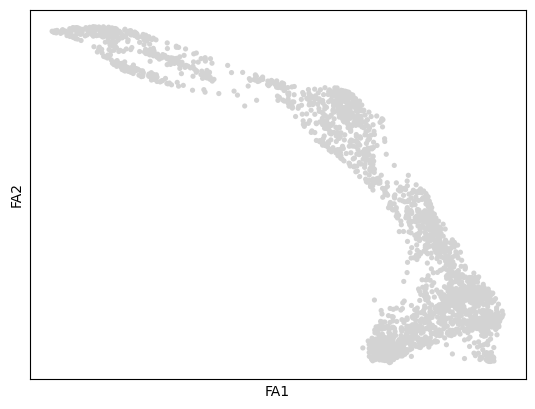

In [19]:
sc.pl.draw_graph(adata)

## Clustering

In [20]:
sc.tl.leiden(adata)

C:\Users\willi\AppData\Local\Temp\ipykernel_57556\3467744858.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


## PAGA trajectory inference

In [21]:
sc.tl.paga(adata, groups="leiden")

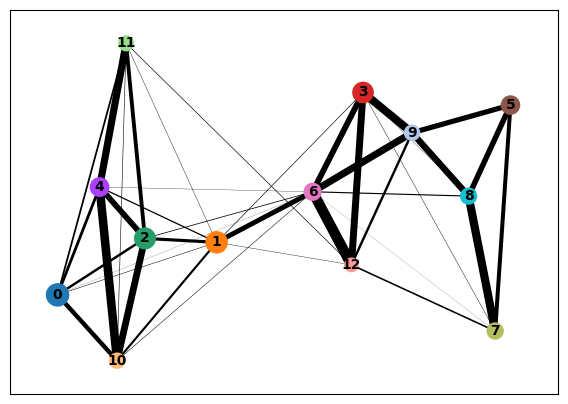

In [22]:
sc.pl.paga(adata, color=["leiden"])

### PAGA informed graph

In [23]:
sc.tl.draw_graph(adata, init_pos="paga")

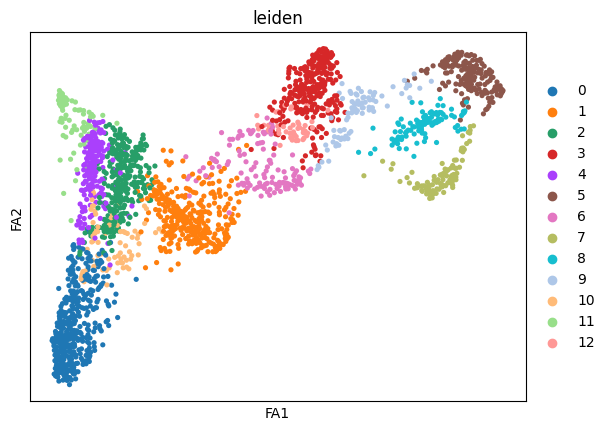

In [24]:
sc.pl.draw_graph(adata, color="leiden")

## Pseudotime: use root node

In [25]:
adata.uns["iroot"] = adata.obs_names.get_loc("mESC_d0_p2_A7_S7")

In [26]:
sc.tl.dpt(adata)

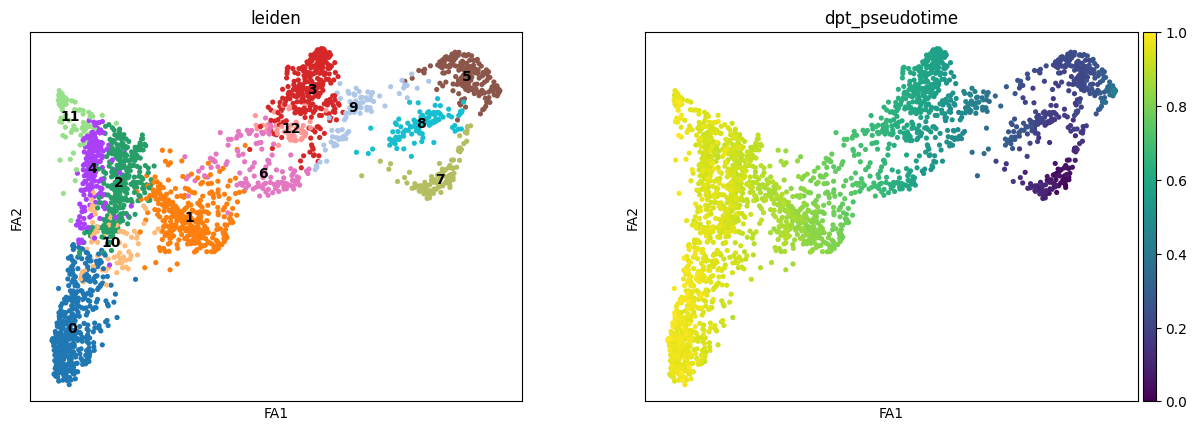

In [27]:
sc.pl.draw_graph(adata, color=["leiden", "dpt_pseudotime"], legend_loc="on data")

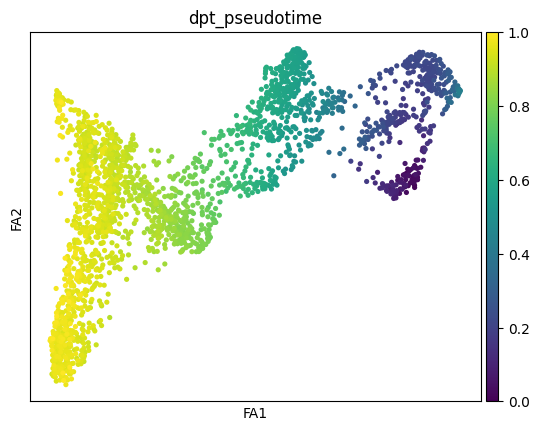

In [28]:
sc.pl.draw_graph(adata, color=["dpt_pseudotime"])

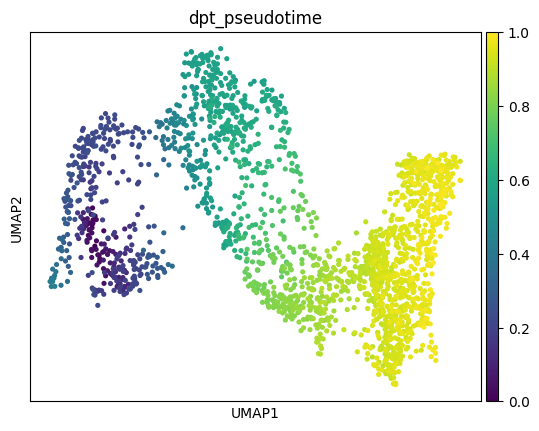

In [29]:
sc.pl.umap(adata, color=["dpt_pseudotime"])

In [30]:
adata.obsp['connectivities']

<Compressed Sparse Row sparse matrix of dtype 'float32'
	with 45160 stored elements and shape (2149, 2149)>

In [31]:
import matplotlib.pyplot as plt

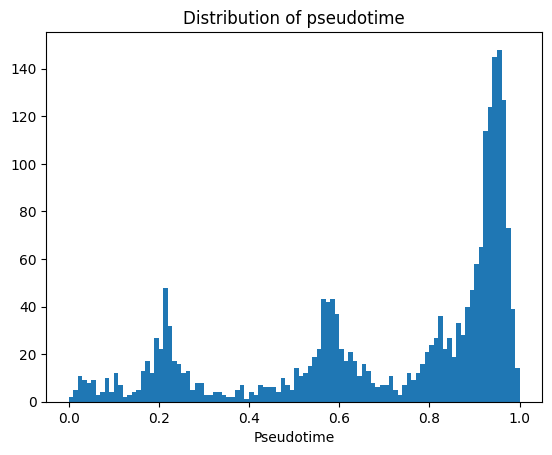

In [32]:
plt.hist(adata.obs['dpt_pseudotime'].to_numpy(dtype=float), bins=100);
plt.xlabel("Pseudotime")
plt.title("Distribution of pseudotime")
plt.show()

In [ ]:
# save adata
#adata.write_h5ad("./Data/mouse_processed.h5ad")

# Notes

- distribution of pseudotimes different to that of R results: still peaked but less extreme, and many cells with values close to 1, where previously there were none
- still unclear about many steps of the process
- should days / plates be used as a batch?

How should pseudotime be used?

- potentially multiple branches to trajectory, so may not make sense to just use pseudotime difference as way to group cells
    - could use connectivities computed to obtains groups?

But this eventually leads to velocity, keep things simple

# Pseudotime Correlation Analysis

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy

In [3]:
rng = np.random.default_rng(423)

In [4]:
# load data
adata = ad.read_h5ad("./Data/mouse_processed.h5ad")

In [5]:
# extract pseudotime
pseudotime = adata.obs['dpt_pseudotime'].to_numpy(dtype=float)

# extract counts
counts = adata.layers['counts']

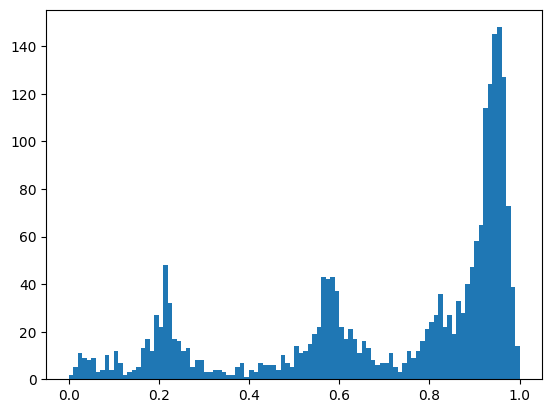

In [6]:
plt.hist(pseudotime, bins=100);

In [45]:
# separate cells by day
mask_d0 = adata.obs.index.str.contains("d0")
mask_d4 = adata.obs.index.str.contains("d4")
mask_d8 = adata.obs.index.str.contains("d8")
mask_d12 = adata.obs.index.str.contains("d12")

# also separate extra p2 & p3 day 0 cells
mask_p2 = adata.obs.index.str.contains("p2")
mask_p3 = adata.obs.index.str.contains("p3")

# select pseudotime
pseudotime_d0 = pseudotime[mask_d0]
pseudotime_d4 = pseudotime[mask_d4]
pseudotime_d8 = pseudotime[mask_d8]
pseudotime_d12 = pseudotime[mask_d12]

pseudotime_d0_only = pseudotime[mask_d0 & ~mask_p2 & ~mask_p3]
pseudotime_d0_p2 = pseudotime[mask_p2]
pseudotime_d0_p3 = pseudotime[mask_p3]

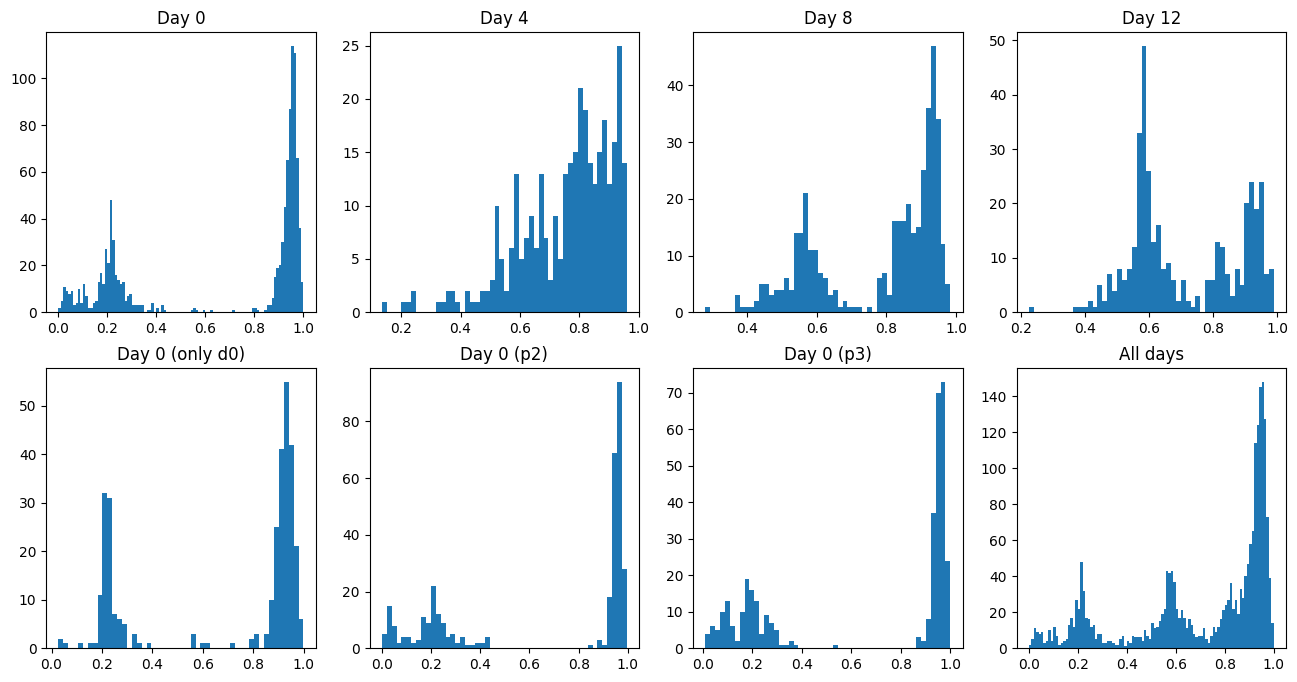

In [56]:
fig, axs = plt.subplots(2, 4, figsize=(16, 8))
axs[0, 0].hist(pseudotime_d0, bins=100)
axs[0, 0].set_title("Day 0")
axs[0, 1].hist(pseudotime_d4, bins=50)
axs[0, 1].set_title("Day 4")
axs[0, 2].hist(pseudotime_d8, bins=50)
axs[0, 2].set_title("Day 8")
axs[0, 3].hist(pseudotime_d12, bins=50)
axs[0, 3].set_title("Day 12")

axs[1, 0].hist(pseudotime_d0_only, bins=50)
axs[1, 0].set_title("Day 0 (only d0)")
axs[1, 1].hist(pseudotime_d0_p2, bins=50)
axs[1, 1].set_title("Day 0 (p2)")
axs[1, 2].hist(pseudotime_d0_p3, bins=50)
axs[1, 2].set_title("Day 0 (p3)")

axs[1, 3].hist(pseudotime, bins=100)
axs[1, 3].set_title("All days")
plt.show()

In [57]:
'''
# select genes: use highly variable and high mean expression as filter
selected_genes = adata.var[(adata.var['highly_variable']) & (adata.var['mean_counts'] > 10)]
selected_genes.head()

# random pair
g1, g2 = rng.choice(selected_genes.shape[0], size=2, replace=False)
g1_name = selected_genes.index[g1]
g2_name = selected_genes.index[g2]
'''

g1_name = "Dmtn"
g2_name = "Snx27"
print(f"{g1_name}, {g2_name}")

# get indices in full dataset
g1_idx = adata.var.index.to_list().index(g1_name)
g2_idx = adata.var.index.to_list().index(g2_name)

# get counts
sample = counts[:, [g1_idx, g2_idx]]

Dmtn, Snx27


## Functions

In [58]:
def correlation_fixed_time_window(sample, pseudotime, width, step):
    
    # overall correlation
    total_corr = float(scipy.stats.pearsonr(sample[:, 0], sample[:, 1]).statistic)
    #plt.axhline(total_corr, color="red")

    # store window correlations, times, cells
    window_corrs = []
    window_times = []
    window_cells = []

    # for each interval
    t = -step
    while t <= 1 - width - step:

        # increment time
        t += step

        # select cells with pseudotime in interval
        mask = (pseudotime > t) & (pseudotime < t + width)

        # store
        window_times.append([t, t + width])
        window_cells.append(mask.sum())

        # check for <= 1 cells
        if mask.sum() < 2:
            window_corrs.append(np.nan)
            #plt.axvspan(t, t + width, color="red", alpha=0.25)
            continue

        g1_window = sample[:, 0][mask]
        g2_window = sample[:, 1][mask]

        # check for constant sample (var = 0 so undefined)
        if np.unique(g1_window).size < 2 or np.unique(g2_window).size < 2:
            window_corrs.append(np.nan)
            #plt.axvspan(t, t + width, color="orange", alpha=0.25)
            continue

        # compute correlation
        corr_window = float(scipy.stats.pearsonr(g1_window, g2_window).statistic)

        # plot
        window_corrs.append(corr_window)
        #plt.plot([t, t + width], [corr_window, corr_window], color="blue")

    # collect data
    data = {
        'type': 'time',
        'total_corr': total_corr,
        'window_corrs': window_corrs,
        'window_times': window_times,
        'window_cells': window_cells
    }

    return data

In [59]:
def correlation_fixed_cells_window(sample, pseudotime, width, step):
    
    # overall correlation
    total_corr = float(scipy.stats.pearsonr(sample[:, 0], sample[:, 1]).statistic)
    #plt.axhline(total_corr, color="red")

    # total number of cells
    C = sample.shape[0]

    # store window correlations, times, cells
    window_corrs = []
    window_times = []
    window_cells = []

    # sort cells and pseudotime by increasing pseudotime
    idxs = pseudotime.argsort()
    g1_sorted = sample[:, 0][idxs]
    g2_sorted = sample[:, 1][idxs]
    t_sorted = pseudotime[idxs]

    # for each interval
    c = -step
    while c < C - width - step:

        # increment cell index
        c += step

        # select cells
        g1_window = g1_sorted[c:(c + width)]
        g2_window = g2_sorted[c:(c + width)]

        # get time interval covered
        t1 = t_sorted[c]
        t2 = t_sorted[c + width]

        # store
        window_times.append([t1, t2])
        window_cells.append(width)

        # check for constant sample (var = 0 so undefined)
        if np.unique(g1_window).size < 2 or np.unique(g2_window).size < 2:
            window_corrs.append(np.nan)
            #plt.axvspan(t1, t2, color="orange", alpha=0.25)
            continue

        # compute correlation
        corr_window = float(scipy.stats.pearsonr(g1_window, g2_window).statistic)

        # plot
        window_corrs.append(corr_window)
        #plt.plot([t1, t2], [corr_window, corr_window], color="blue")

    # collect data
    data = {
        'type': 'cells',
        'total_corr': total_corr,
        'window_corrs': window_corrs,
        'window_times': window_times,
        'window_cells': window_cells
    }

    return data

In [60]:
def plot_window_correlations(data):

    plt.axhline(data['total_corr'], color="grey", linestyle="--", label="All cells")

    for corr, times in zip(data['window_corrs'], data['window_times']):
        if np.isnan(corr):
            plt.axvspan(times[0], times[1], color="red", alpha=0.25)
        else:
            plt.plot([times[0], times[1]], [corr]*2, color="blue")

    plt.xlabel("Pseudotime")
    plt.ylabel("Correlation")
    plt.title(f"Fixed {data['type']} width window correlations")
    plt.legend()
    plt.show()

In [61]:
def plot_window_cells(data):

    plt.scatter(range(len(data['window_cells'])), data['window_cells'], s=5)
    mn = np.min(data['window_cells'])
    plt.axhline(mn, label=f"Min {mn} cells", color="grey", linestyle="--")
    plt.xlabel("Window")
    plt.ylabel("Cells")
    plt.title("Cells per window")
    plt.legend()
    plt.show()

## Fixed time window

### Distinct

In [62]:
fixed_time = correlation_fixed_time_window(sample, pseudotime, 0.1, 0.1)

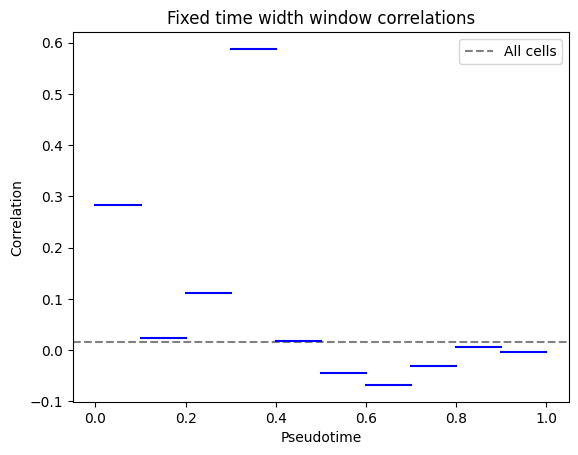

In [282]:
plot_window_correlations(fixed_time)

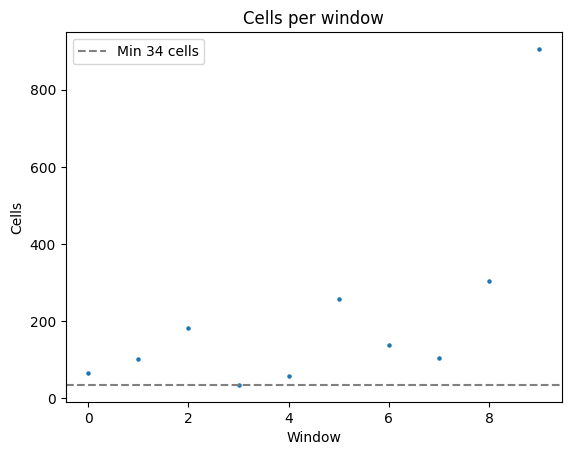

In [283]:
plot_window_cells(fixed_time)

### Overlapping

In [284]:
fixed_time = correlation_fixed_time_window(sample, pseudotime, 0.1, 0.01)

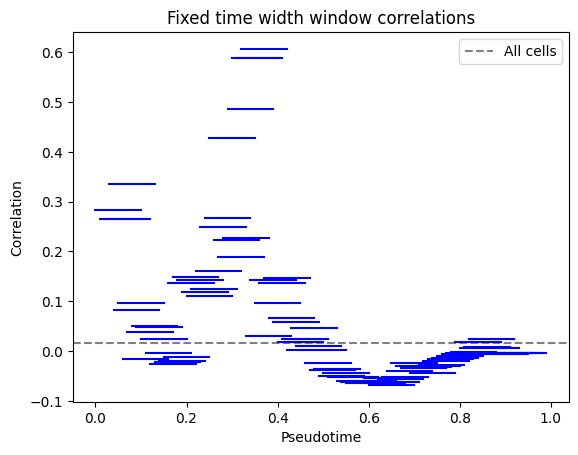

In [285]:
plot_window_correlations(fixed_time)

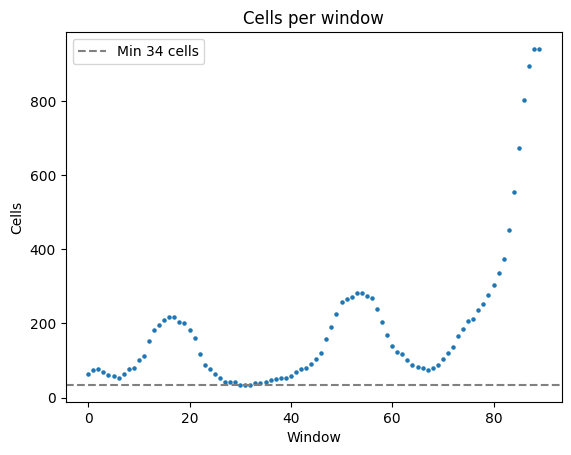

In [286]:
plot_window_cells(fixed_time)

### Wide

In [287]:
fixed_time = correlation_fixed_time_window(sample, pseudotime, 0.33, 0.33)

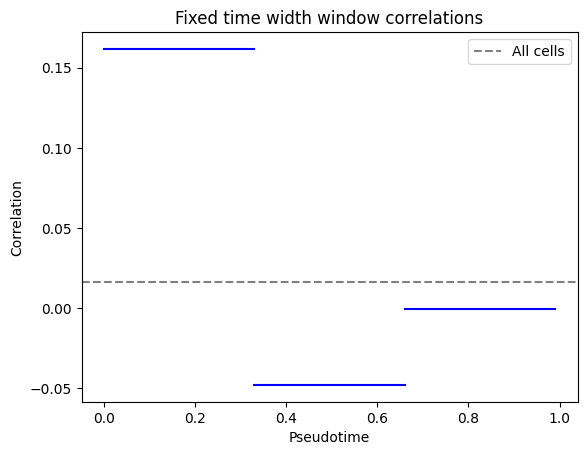

In [288]:
plot_window_correlations(fixed_time)

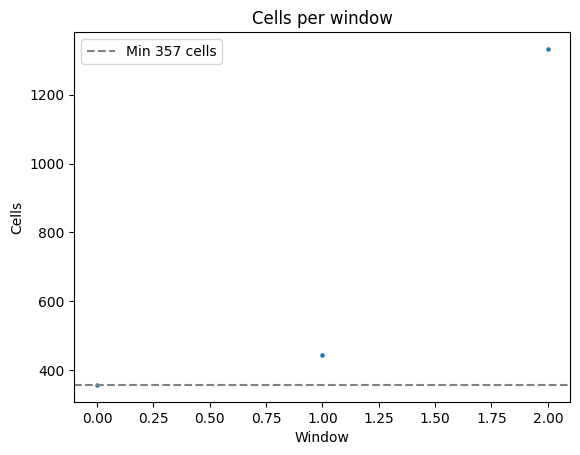

In [289]:
plot_window_cells(fixed_time)

## Fixed cells window

### Distinct

In [291]:
fixed_cells = correlation_fixed_cells_window(sample, pseudotime, 100, 100)

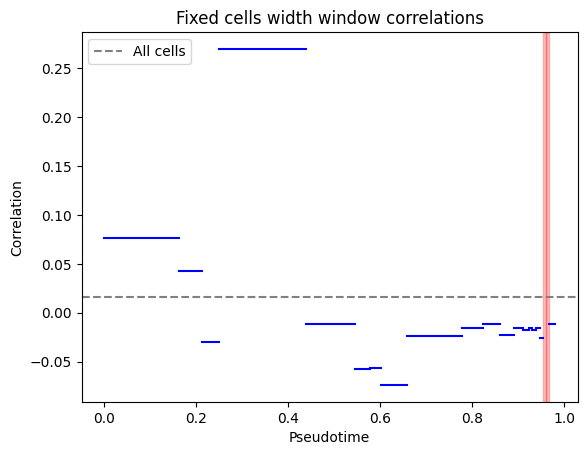

In [292]:
plot_window_correlations(fixed_cells)

### Overlapping

In [294]:
fixed_cells = correlation_fixed_cells_window(sample, pseudotime, 100, 10)

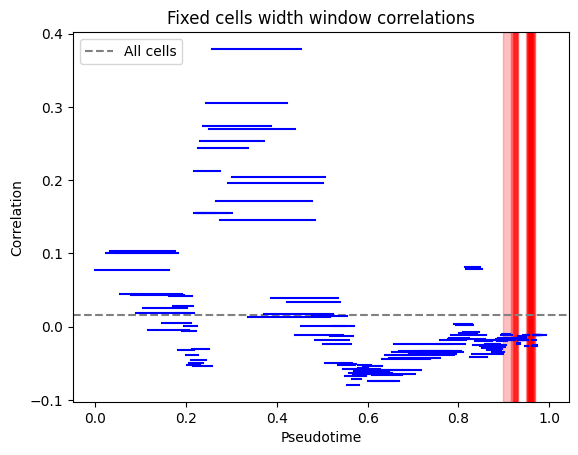

In [295]:
plot_window_correlations(fixed_cells)

### Wide

In [296]:
fixed_cells = correlation_fixed_cells_window(sample, pseudotime, 500, 500)

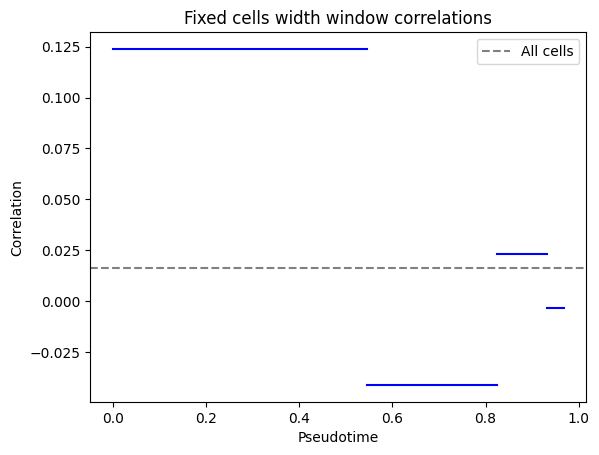

In [297]:
plot_window_correlations(fixed_cells)

## Day windows

In [64]:
def correlation_day(sample, pseudotime):
    
    # overall correlation
    total_corr = float(scipy.stats.pearsonr(sample[:, 0], sample[:, 1]).statistic)
    #plt.axhline(total_corr, color="red")

    # store window correlations, times, cells
    window_corrs = []
    window_times = []
    window_cells = []

    # separate cells by day
    mask_d0 = adata.obs.index.str.contains("d0")
    mask_d4 = adata.obs.index.str.contains("d4")
    mask_d8 = adata.obs.index.str.contains("d8")
    mask_d12 = adata.obs.index.str.contains("d12")

    # also separate extra p2 & p3 day 0 cells
    #mask_p2 = adata.obs.index.str.contains("p2")
    #mask_p3 = adata.obs.index.str.contains("p3")
    #mask_d0_only = mask_d0 & ~mask_p2 & ~mask_p3

    masks = [mask_d0, mask_d4, mask_d8, mask_d12]

    # for each day
    for mask in masks:

        # select pseudotime
        pseudotime_d = pseudotime[mask]
        tmin = np.min(pseudotime_d)
        tmax = np.max(pseudotime_d)

        # store
        window_times.append([tmin, tmax])
        window_cells.append(mask.sum())

        # check for <= 1 cells
        if mask.sum() < 2:
            window_corrs.append(np.nan)
            #plt.axvspan(t, t + width, color="red", alpha=0.25)
            continue

        g1_window = sample[:, 0][mask]
        g2_window = sample[:, 1][mask]

        # check for constant sample (var = 0 so undefined)
        if np.unique(g1_window).size < 2 or np.unique(g2_window).size < 2:
            window_corrs.append(np.nan)
            #plt.axvspan(t, t + width, color="orange", alpha=0.25)
            continue

        # compute correlation
        corr_window = float(scipy.stats.pearsonr(g1_window, g2_window).statistic)

        # plot
        window_corrs.append(corr_window)
        #plt.plot([t, t + width], [corr_window, corr_window], color="blue")

    # collect data
    data = {
        'type': 'day',
        'total_corr': total_corr,
        'window_corrs': window_corrs,
        'window_times': window_times,
        'window_cells': window_cells
    }

    return data

In [65]:
fixed_day = correlation_day(sample, pseudotime)

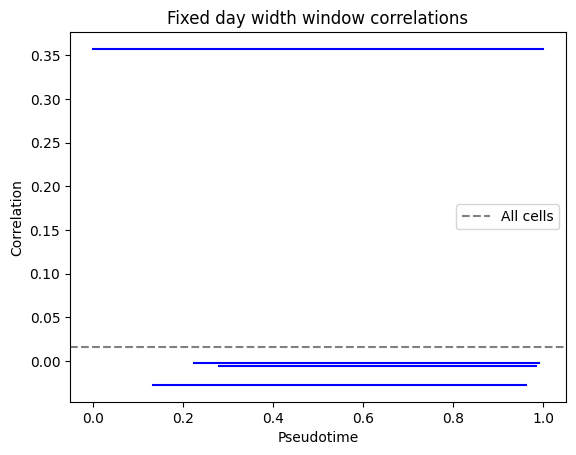

In [66]:
plot_window_correlations(fixed_day)

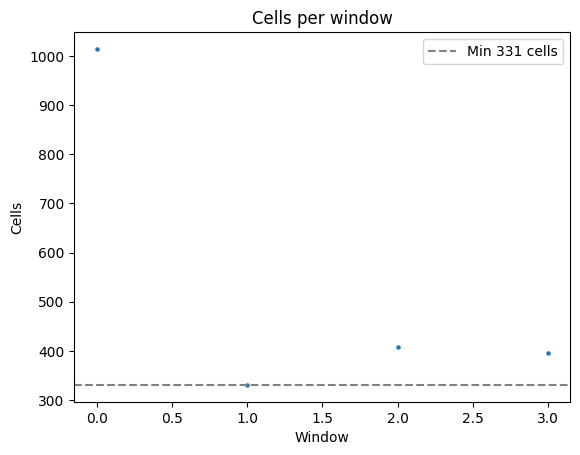

In [81]:
plot_window_cells(fixed_day)

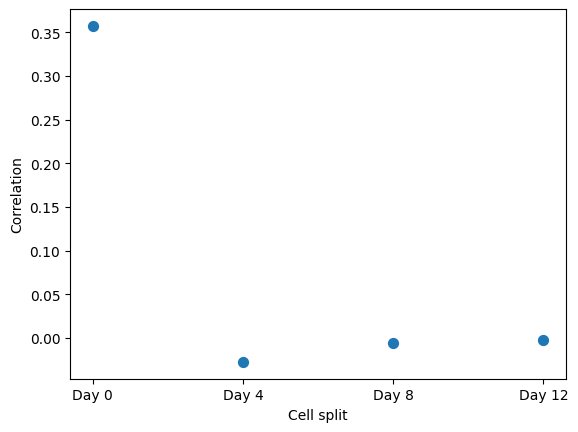

In [79]:
fig, axs = plt.subplots()
axs.scatter(range(4), fixed_day['window_corrs'], s=50)
axs.set_xticks([0, 1, 2, 3])
axs.set_xticklabels(["Day 0", "Day 4", "Day 8", "Day 12"])
axs.set_ylabel("Correlation")
axs.set_xlabel("Cell split")
plt.show()

# Simulation test

- define correlation as function of time: sine
- use data pseudotime as sampling time
- run correlation window methods on sample

In [313]:
def correlated_sample(t):

    p = np.sin(t * 2 * np.pi)

    mu = np.array([0, 0])
    Sigma = np.array([
        [1.0, p],
        [p, 1.0]
    ])

    x = rng.multivariate_normal(mu, Sigma)

    return x

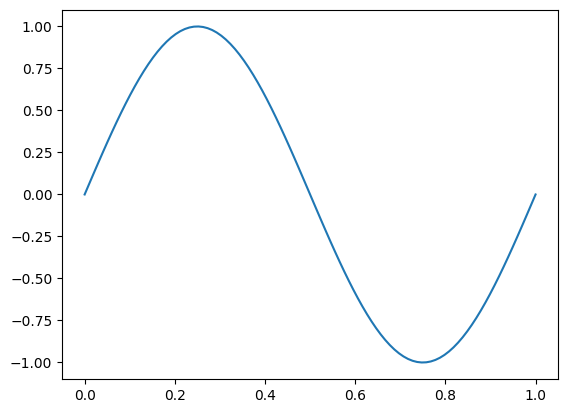

In [ ]:
# correlation function
t = np.linspace(0, 1, 100)
p = np.sin(t * 2 * np.pi)
plt.plot(t, p)

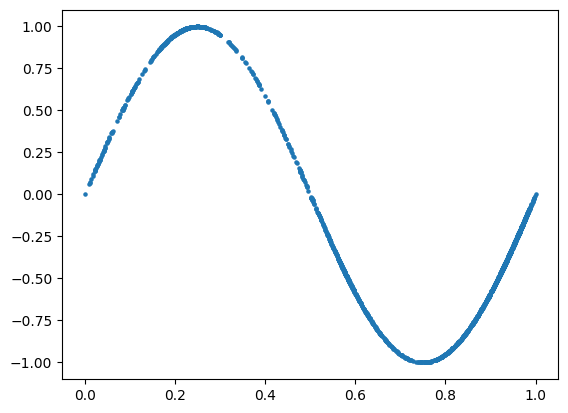

In [ ]:
# correlation at sampling points
t = pseudotime
p = np.sin(t * 2 * np.pi)
plt.scatter(t, p, s=5)

In [ ]:
# sample
N = len(pseudotime)
sample = np.empty((N, 2))
for i, t in enumerate(pseudotime):
    sample[i, :] = correlated_sample(t)

In [320]:
fixed_time = correlation_fixed_time_window(sample, pseudotime, 0.1, 0.01)

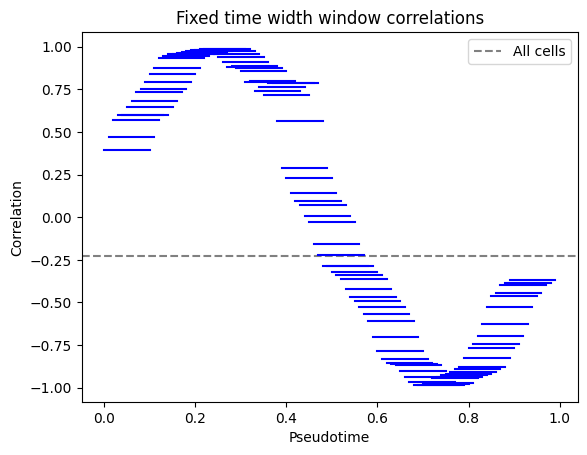

In [321]:
plot_window_correlations(fixed_time)

In [322]:
fixed_time = correlation_fixed_time_window(sample, pseudotime, 0.1, 0.1)

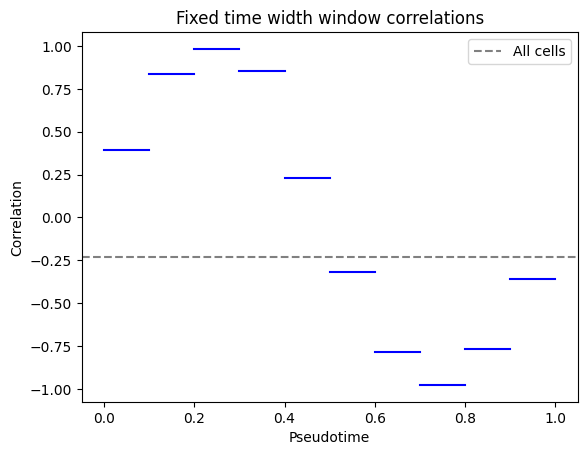

In [323]:
plot_window_correlations(fixed_time)

In [324]:
fixed_cells = correlation_fixed_cells_window(sample, pseudotime, 100, 100)

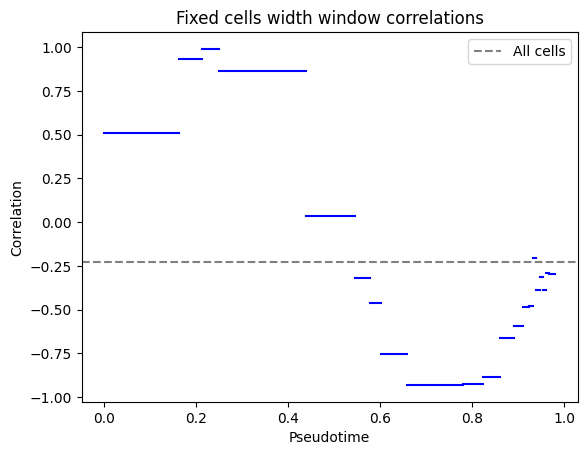

In [325]:
plot_window_correlations(fixed_cells)

In [326]:
fixed_cells = correlation_fixed_cells_window(sample, pseudotime, 100, 10)

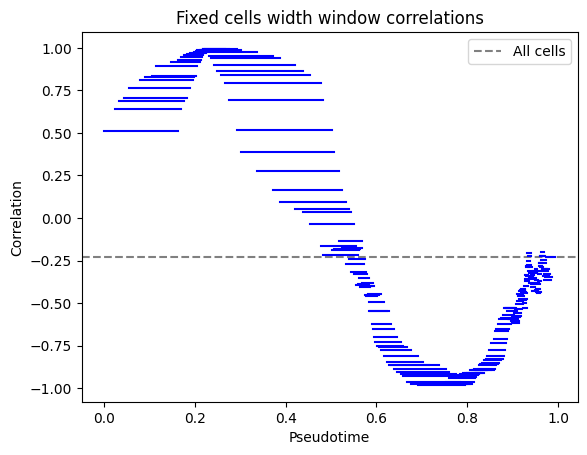

In [327]:
plot_window_correlations(fixed_cells)